# SIH26158 - isolated frontend and sparse-mapping A/B experiment

This notebook preserves the accepted `full253_opt_adaptive_1088_i4_s10` output as a read-only
reference. It first replaces 1,012 random MP4 seeks with one forward decode and requires the exact
same 253 source-frame indices. It then screens calibrated global SfM against the accepted sparse
geometry. The full 1088 dense pipeline is run only after both screening stages pass.

The accepted reference took 42.61 minutes: keyframe extraction took 9.80 minutes and incremental
pose-prior sparse mapping took 12.41 minutes. Dense settings stay frozen at stride 2, adaptive
anchors, ten source images, 1088 pixels, four iterations, and fifteen samples.

Select **Runtime > Change runtime type > T4 GPU**. Run cells in order. Cell 2 restarts the runtime
once; continue from Cell 3. Stop after Cell 9 and inspect the screening decision before Cell 11.

In [1]:
# CELL 1 - mount Drive and verify the separate project and accepted 1088 reference
import os, subprocess
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB'
REFERENCE_OUTPUT = (
    '/content/drive/MyDrive/SIH26158_HF_Drone_Optimization/'
    'outputs/adaptive_mvs_optimization/full253_opt_adaptive_1088_i4_s10'
)
assert os.path.isfile(f'{PROJECT_DIR}/requirements.txt'), (
    'Extract the ZIP to exactly MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB.'
)
assert os.path.isfile(f'{REFERENCE_OUTPUT}/run_report.json')
assert os.path.isfile(f'{REFERENCE_OUTPUT}/frames.csv')
gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True,
)
assert gpu.returncode == 0, 'No NVIDIA GPU detected. Select a T4 GPU runtime.'
print('GPU:', gpu.stdout.strip())
print('A/B project:', PROJECT_DIR)
print('Read-only 1088 reference:', REFERENCE_OUTPUT)

Mounted at /content/drive
GPU: Tesla T4, 15360 MiB
A/B project: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB
Read-only 1088 reference: /content/drive/MyDrive/SIH26158_HF_Drone_Optimization/outputs/adaptive_mvs_optimization/full253_opt_adaptive_1088_i4_s10


In [2]:
# CELL 2 - install Conda once; this intentionally restarts the runtime
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [1]:
# CELL 3 - install CUDA COLMAP, global SfM tools, and project dependencies
import os, shutil, subprocess, sys
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB'
REFERENCE_OUTPUT = (
    '/content/drive/MyDrive/SIH26158_HF_Drone_Optimization/'
    'outputs/adaptive_mvs_optimization/full253_opt_adaptive_1088_i4_s10'
)
assert shutil.which('mamba'), 'Conda is missing. Run Cell 2 and wait for its restart.'
pin = '/usr/local/conda-meta/pinned'
if os.path.exists(pin):
    os.remove(pin)
subprocess.run(
    ['mamba', 'install', '-y', '-q', '-c', 'conda-forge', 'colmap', 'libfaiss', 'openimageio'],
    check=True,
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'],
    check=True,
)
check = subprocess.run(['colmap', '-h'], capture_output=True, text=True, errors='replace')
header = (check.stdout or '') + (check.stderr or '')
print('\n'.join(header.splitlines()[:14]))
for command in ('pose_prior_mapper', 'global_mapper', 'view_graph_calibrator'):
    assert command in header, f'Installed COLMAP does not expose {command}.'
assert check.returncode == 0 and 'COLMAP' in header and 'CUDA' in header
subprocess.run(
    [sys.executable, '-m', 'unittest', 'discover', '-s', 'tests', '-v'],
    cwd=PROJECT_DIR, check=True,
)
print('Installation, global-SfM command checks, and tests complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLMAP 4.2.0 (Commit Unknown on Unknown with CUDA)
Usage:
  colmap [command] [options]
Documentation:
  https://colmap.github.io/
Example usage:
  colmap help [ -h, --help ]
  colmap gui
  colmap gui -h [ --help ]
  colmap automatic_reconstructor -h [ --help ]
  colmap automatic_reconstructor --image_path IMAGES --workspace_path WORKSPACE
  colmap feature_extractor --image_path IMAGES --database_path DATABASE
  colmap exhaustive_matcher --database_path DATABASE
  colmap mapper --image_path IMAGES --database_path DATABASE --output_path MODEL
Installation, global-SfM command checks, and tests complete.


In [2]:
# CELL 4 - download and normalize the same HF Drone video and telemetry
import json, os, subprocess, sys

DATA_DIR = '/content/hf_drone_dataset'
PREPARED_DIR = '/content/hf_drone_prepared'
VIDEO = f'{DATA_DIR}/20240629164410_0023_D.mp4'
TELEMETRY = f'{PREPARED_DIR}/hf_drone_telemetry.csv'
env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_DIR + os.pathsep + env.get('PYTHONPATH', '')
subprocess.run([
    sys.executable, '-m', 'sih_drone_pipeline.dataset',
    '--dataset', 'hf-drone', '--download-dir', DATA_DIR, '--output', PREPARED_DIR,
], cwd=PROJECT_DIR, env=env, check=True)
manifest = json.load(open(f'{PREPARED_DIR}/dataset_manifest.json'))
print(json.dumps({
    'telemetry_samples': manifest['telemetry_samples'],
    'telemetry_duration_s': manifest['telemetry_duration_s'],
    'recording_segments_found': manifest['recording_segments_found'],
    'gps_satellites_median': manifest['gps_satellites_median'],
}, indent=2))

{
  "telemetry_samples": 2525,
  "telemetry_duration_s": 252.4,
  "recording_segments_found": 2,
  "gps_satellites_median": 25.0
}


In [3]:
# CELL 5 - configure isolated screening and final-run locations
import json, os

EXPERIMENT_ROOT = f'{PROJECT_DIR}/outputs/frontend_sparse_ab'
KEYFRAME_WORKSPACE = '/content/sih26158_sequential_keyframe_screen'
KEYFRAME_IMAGES = f'{KEYFRAME_WORKSPACE}/images'
KEYFRAME_MANIFEST = f'{KEYFRAME_WORKSPACE}/frames.csv'
SPARSE_OUTPUT = f'{EXPERIMENT_ROOT}/global_sparse_screen'
SPARSE_WORKSPACE = '/content/sih26158_global_sparse_screen'
FULL_RUN_NAME = 'full253_sequential_global_1088'
FULL_OUTPUT = f'{EXPERIMENT_ROOT}/{FULL_RUN_NAME}'
FULL_WORKSPACE = f'/content/sih26158_{FULL_RUN_NAME}'
TARGET_FRAMES = 253
MAX_WIDTH = 1920
RESET_WORKSPACES = True
REUSE_COMPLETED = True
os.makedirs(EXPERIMENT_ROOT, exist_ok=True)

reference = json.load(open(f'{REFERENCE_OUTPUT}/run_report.json'))
reference_keyframe_s = reference['workflow_steps']['keyframe_extraction']['seconds']
reference_sparse_s = reference['stages']['sparse_mapping']['seconds']
print('Reference total (min):', round(reference['wall_clock_seconds'] / 60, 2))
print('Reference keyframe extraction (min):', round(reference_keyframe_s / 60, 2))
print('Reference sparse mapping (min):', round(reference_sparse_s / 60, 2))
print('Reference registered images:', reference['sparse_metrics']['registered_images'])
print('Separate experiment root:', EXPERIMENT_ROOT)

Reference total (min): 42.61
Reference keyframe extraction (min): 9.8
Reference sparse mapping (min): 12.41
Reference registered images: 207
Separate experiment root: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab


In [4]:
# CELL 6 - benchmark one-pass sequential keyframe extraction against the accepted manifest
import json, os, shutil, sys, time
import pandas as pd

sys.path.insert(0, PROJECT_DIR)
from sih_drone_pipeline.extract_keyframes import extract_keyframes
from sih_drone_pipeline.telemetry import load_telemetry

if RESET_WORKSPACES and os.path.isdir(KEYFRAME_WORKSPACE):
    shutil.rmtree(KEYFRAME_WORKSPACE)
os.makedirs(KEYFRAME_IMAGES, exist_ok=True)
telemetry_samples = load_telemetry(TELEMETRY)
started = time.perf_counter()
records = extract_keyframes(
    VIDEO,
    KEYFRAME_IMAGES,
    target_frames=TARGET_FRAMES,
    max_width=MAX_WIDTH,
    manifest_path=KEYFRAME_MANIFEST,
    selection_mode='geometry',
    telemetry_samples=telemetry_samples,
    decode_mode='sequential',
)
candidate_keyframe_s = time.perf_counter() - started
reference_frames = pd.read_csv(f'{REFERENCE_OUTPUT}/frames.csv')
candidate_frames = pd.read_csv(KEYFRAME_MANIFEST)
reference_ids = reference_frames['source_frame'].astype(int).tolist()
candidate_ids = candidate_frames['source_frame'].astype(int).tolist()
same_source_frames = reference_ids == candidate_ids
differences = [
    {'output_index': index, 'reference': before, 'candidate': after}
    for index, (before, after) in enumerate(zip(reference_ids, candidate_ids))
    if before != after
]
selection_metadata = json.load(open(KEYFRAME_MANIFEST.replace('.csv', '.selection.json')))
keyframe_decision = {
    'reference_seconds': reference_keyframe_s,
    'candidate_seconds': round(candidate_keyframe_s, 2),
    'reference_minutes': round(reference_keyframe_s / 60, 2),
    'candidate_minutes': round(candidate_keyframe_s / 60, 2),
    'speedup': reference_keyframe_s / candidate_keyframe_s,
    'same_253_source_frames': same_source_frames and len(candidate_ids) == 253,
    'different_frame_count': len(differences),
    'runtime_improved': candidate_keyframe_s < reference_keyframe_s,
    'thirty_percent_target': candidate_keyframe_s <= 0.70 * reference_keyframe_s,
    'decode_evidence': selection_metadata,
}
KEYFRAME_PASS = (
    keyframe_decision['same_253_source_frames'] and keyframe_decision['runtime_improved']
)
keyframe_decision['screen_pass'] = KEYFRAME_PASS
json.dump(
    keyframe_decision,
    open(f'{EXPERIMENT_ROOT}/keyframe_decision.json', 'w'),
    indent=2,
)
candidate_frames.to_csv(f'{EXPERIMENT_ROOT}/sequential_frames.csv', index=False)
print(json.dumps(keyframe_decision, indent=2))
if differences:
    display(pd.DataFrame(differences[:20]))
assert keyframe_decision['same_253_source_frames'], (
    'Sequential decode changed the selected source frames; do not combine it with sparse changes.'
)

{
  "reference_seconds": 587.88,
  "candidate_seconds": 147.9,
  "reference_minutes": 9.8,
  "candidate_minutes": 2.46,
  "speedup": 3.97494908284094,
  "same_253_source_frames": true,
  "different_frame_count": 0,
  "runtime_improved": true,
  "thirty_percent_target": true,
  "decode_evidence": {
    "selection_mode": "fixed",
    "keyframe_selection_mode": "geometry",
    "keyframe_decode_mode": "sequential",
    "video_duration_s": 251.51793333333333,
    "source_fps": 29.97002997002997,
    "requested_sample_fps": 1.0,
    "max_frames": 1200,
    "selected_frames": 253,
    "candidate_frames": 1012,
    "seek_operations": 0,
    "sequential_grabbed_frames": 6526,
    "timing_seconds": {
      "decode": 118.67,
      "score_candidates": 25.56,
      "select_candidates": 0.03,
      "write_selected_jpegs": 3.57
    },
    "effective_sample_fps": 1.0058924890445187,
    "baseline_target_m": 5.514860466663548,
    "median_selected_baseline_m": 5.7268541244917905,
    "median_selected_p

,process,minutes
0,Accepted random-seek extraction,9.80
1,New sequential extraction,2.46


,subprocess,seconds,minutes
0,Decode,118.67,1.98
1,Score Candidates,25.56,0.43
3,Write Selected Jpegs,3.57,0.06
2,Select Candidates,0.03,0.00


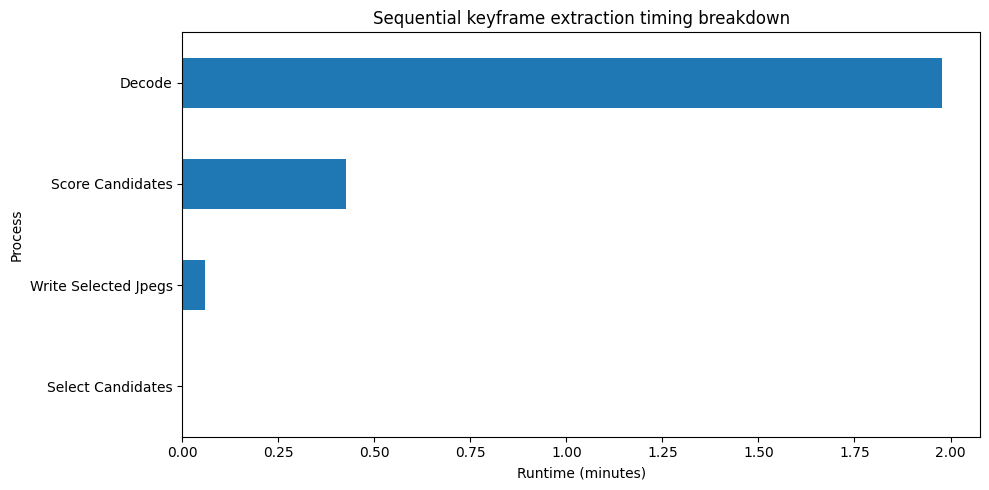

In [5]:
# CELL 7 - display the keyframe timing breakdown
import matplotlib.pyplot as plt
import pandas as pd

timing = keyframe_decision['decode_evidence']['timing_seconds']
rows = [
    {'process': 'Accepted random-seek extraction', 'minutes': reference_keyframe_s / 60},
    {'process': 'New sequential extraction', 'minutes': candidate_keyframe_s / 60},
]
display(pd.DataFrame(rows).style.format({'minutes': '{:.2f}'}))
breakdown = pd.DataFrame([
    {'subprocess': name.replace('_', ' ').title(), 'seconds': seconds}
    for name, seconds in timing.items()
]).sort_values('seconds', ascending=False)
breakdown['minutes'] = breakdown['seconds'] / 60
display(breakdown.style.format({'seconds': '{:.2f}', 'minutes': '{:.2f}'}))
ax = breakdown.sort_values('seconds').plot.barh(
    x='subprocess', y='minutes', legend=False, figsize=(10, 5),
    title='Sequential keyframe extraction timing breakdown',
)
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Process')
plt.tight_layout()
plt.savefig(f'{EXPERIMENT_ROOT}/keyframe_timing.png', dpi=180, bbox_inches='tight')
plt.show()

In [6]:
# CELL 8 - run the global-SfM sparse screen only; dense reconstruction is deliberately skipped
import json, os, shutil, subprocess, sys, time

if REUSE_COMPLETED and os.path.isfile(f'{SPARSE_OUTPUT}/run_report.json'):
    print('Reusing completed sparse-screen report:', SPARSE_OUTPUT)
else:
    if RESET_WORKSPACES and os.path.isdir(SPARSE_WORKSPACE):
        shutil.rmtree(SPARSE_WORKSPACE)
    os.makedirs(SPARSE_OUTPUT, exist_ok=True)
    command = [
        sys.executable, '-m', 'sih_drone_pipeline', 'run',
        '--video', VIDEO, '--telemetry', TELEMETRY,
        '--workspace', SPARSE_WORKSPACE, '--output', SPARSE_OUTPUT,
        '--quality', 'draft', '--target-frames', str(TARGET_FRAMES),
        '--max-width', str(MAX_WIDTH), '--keyframe-mode', 'geometry',
        '--keyframe-decode-mode', 'sequential',
        '--mapper', 'global', '--mapper-ba-gpu', '--sparse-only',
    ]
    print('Running sparse screen:', ' '.join(command))
    started = time.time()
    result = subprocess.run(command, cwd=PROJECT_DIR, env=env)
    print('Sparse-screen wall time (min):', round((time.time() - started) / 60, 2))
    if os.path.isdir(f'{SPARSE_WORKSPACE}/logs'):
        shutil.copytree(f'{SPARSE_WORKSPACE}/logs', f'{SPARSE_OUTPUT}/logs', dirs_exist_ok=True)
    assert result.returncode == 0, 'Global sparse screen failed; inspect SPARSE_OUTPUT/logs.'
    shutil.copy2(f'{PREPARED_DIR}/dataset_manifest.json', f'{SPARSE_OUTPUT}/dataset_manifest.json')
screen = json.load(open(f'{SPARSE_OUTPUT}/run_report.json'))
print('Global registered images:', screen['sparse_metrics']['registered_images'])
print('Global reprojection error (px):', screen['sparse_metrics']['mean_reprojection_error_px'])
print('Global GPS RMSE (m):', screen['validation']['gps_alignment_rmse_m'])

Running sparse screen: /usr/bin/python3.real -m sih_drone_pipeline run --video /content/hf_drone_dataset/20240629164410_0023_D.mp4 --telemetry /content/hf_drone_prepared/hf_drone_telemetry.csv --workspace /content/sih26158_global_sparse_screen --output /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/global_sparse_screen --quality draft --target-frames 253 --max-width 1920 --keyframe-mode geometry --keyframe-decode-mode sequential --mapper global --mapper-ba-gpu --sparse-only
Sparse-screen wall time (min): 30.52
Global registered images: 243
Global reprojection error (px): 0.409315
Global GPS RMSE (m): 118.24043141984828


In [7]:
# CELL 9 - evaluate the sparse screen before spending time on dense reconstruction
import json
import pandas as pd

screen = json.load(open(f'{SPARSE_OUTPUT}/run_report.json'))
global_mapping_s = screen['stages']['sparse_mapping']['seconds']
calibration_s = screen['stages'].get('view_graph_calibration', {}).get('seconds', 0.0)
global_sparse_logical_s = global_mapping_s + calibration_s
screen_frames = pd.read_csv(f'{SPARSE_OUTPUT}/frames.csv')['source_frame'].astype(int).tolist()
sparse_gates = {
    'same_253_source_frames': screen_frames == reference_ids and len(screen_frames) == 253,
    'registered_images_at_least_205': screen['sparse_metrics']['registered_images'] >= 205,
    'reprojection_no_more_than_reference_plus_0_03_px': (
        screen['sparse_metrics']['mean_reprojection_error_px']
        <= reference['sparse_metrics']['mean_reprojection_error_px'] + 0.03
    ),
    'gps_rmse_no_more_than_reference_plus_0_15_m': (
        screen['validation']['gps_alignment_rmse_m']
        <= reference['validation']['gps_alignment_rmse_m'] + 0.15
    ),
    'global_sparse_time_improved': global_sparse_logical_s < reference_sparse_s,
}
SPARSE_PASS = all(sparse_gates.values())
sparse_decision = {
    'reference_sparse_mapping_seconds': reference_sparse_s,
    'view_graph_calibration_seconds': calibration_s,
    'global_mapping_seconds': global_mapping_s,
    'candidate_logical_sparse_seconds': global_sparse_logical_s,
    'candidate_logical_sparse_minutes': round(global_sparse_logical_s / 60, 2),
    'twenty_percent_runtime_target': global_sparse_logical_s <= 0.80 * reference_sparse_s,
    'quality_and_runtime_gates': sparse_gates,
    'screen_pass': SPARSE_PASS,
    'surface_accuracy': 'Not evaluated; sparse camera diagnostics do not prove surface accuracy.',
}
json.dump(
    sparse_decision,
    open(f'{EXPERIMENT_ROOT}/sparse_decision.json', 'w'),
    indent=2,
)
display(pd.DataFrame([
    {'method': 'Accepted pose-prior incremental', 'logical_sparse_min': reference_sparse_s / 60,
     'registered': reference['sparse_metrics']['registered_images'],
     'reprojection_px': reference['sparse_metrics']['mean_reprojection_error_px'],
     'gps_rmse_m': reference['validation']['gps_alignment_rmse_m']},
    {'method': 'Candidate calibrated global', 'logical_sparse_min': global_sparse_logical_s / 60,
     'registered': screen['sparse_metrics']['registered_images'],
     'reprojection_px': screen['sparse_metrics']['mean_reprojection_error_px'],
     'gps_rmse_m': screen['validation']['gps_alignment_rmse_m']},
]))
print(json.dumps(sparse_decision, indent=2))
print('\nRUN CELL 11 ONLY WHEN screen_pass IS true.')

,method,logical_sparse_min,registered,reprojection_px,gps_rmse_m
0,Accepted pose-prior incremental,12.410000,207,0.454488,1.828571
1,Candidate calibrated global,25.210833,243,0.409315,118.240431


{
  "reference_sparse_mapping_seconds": 744.6,
  "view_graph_calibration_seconds": 46.85,
  "global_mapping_seconds": 1465.8,
  "candidate_logical_sparse_seconds": 1512.6499999999999,
  "candidate_logical_sparse_minutes": 25.21,
  "twenty_percent_runtime_target": false,
  "quality_and_runtime_gates": {
    "same_253_source_frames": true,
    "registered_images_at_least_205": true,
    "reprojection_no_more_than_reference_plus_0_03_px": true,
    "gps_rmse_no_more_than_reference_plus_0_15_m": false,
    "global_sparse_time_improved": false
  },
  "screen_pass": false,
  "surface_accuracy": "Not evaluated; sparse camera diagnostics do not prove surface accuracy."
}

RUN CELL 11 ONLY WHEN screen_pass IS true.


In [8]:
# FINAL TEST — sequential extraction + accepted pose-prior + accepted 1088 dense settings
import os, shutil, subprocess, sys, time

FULL_RUN_NAME = "full253_sequential_pose_prior_1088"
FULL_OUTPUT = f"{EXPERIMENT_ROOT}/{FULL_RUN_NAME}"
FULL_WORKSPACE = f"/content/sih26158_{FULL_RUN_NAME}"

assert KEYFRAME_PASS, "Sequential keyframe test did not pass."

command = [
    sys.executable, "-m", "sih_drone_pipeline", "run",
    "--video", VIDEO,
    "--telemetry", TELEMETRY,
    "--workspace", FULL_WORKSPACE,
    "--output", FULL_OUTPUT,
    "--quality", "draft",
    "--target-frames", "253",
    "--max-width", "1920",
    "--dsm-resolution", "0.5",
    "--keyframe-mode", "geometry",
    "--keyframe-decode-mode", "sequential",
    "--mapper", "pose-prior",
    "--gps-prior-std-m", "5.0",
    "--mapper-ba-gpu",
    "--dense-frame-stride", "2",
    "--dense-anchor-mode", "adaptive",
    "--dense-source-images", "10",
    "--dense-max-image-size", "1088",
    "--dense-num-iterations", "4",
    "--dense-num-samples", "15",
]

if os.path.isfile(f"{FULL_OUTPUT}/run_report.json"):
    print("Completed result already exists:", FULL_OUTPUT)
else:
    if os.path.isdir(FULL_WORKSPACE):
        shutil.rmtree(FULL_WORKSPACE)

    os.makedirs(FULL_OUTPUT, exist_ok=True)

    print("Running:", " ".join(command))
    started = time.time()

    result = subprocess.run(
        command,
        cwd=PROJECT_DIR,
        env=env,
    )

    outer_minutes = (time.time() - started) / 60
    print("Outer runtime (min):", round(outer_minutes, 2))

    if os.path.isdir(f"{FULL_WORKSPACE}/logs"):
        shutil.copytree(
            f"{FULL_WORKSPACE}/logs",
            f"{FULL_OUTPUT}/logs",
            dirs_exist_ok=True,
        )

    assert result.returncode == 0, \
        f"Run failed. Inspect: {FULL_OUTPUT}/logs"

verify = subprocess.run([
    sys.executable, "-m", "sih_drone_pipeline", "verify",
    "--output", FULL_OUTPUT,
], cwd=PROJECT_DIR, env=env)

assert verify.returncode == 0, "Output verification failed."
print("Final candidate completed:", FULL_OUTPUT)

Running: /usr/bin/python3.real -m sih_drone_pipeline run --video /content/hf_drone_dataset/20240629164410_0023_D.mp4 --telemetry /content/hf_drone_prepared/hf_drone_telemetry.csv --workspace /content/sih26158_full253_sequential_pose_prior_1088 --output /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/full253_sequential_pose_prior_1088 --quality draft --target-frames 253 --max-width 1920 --dsm-resolution 0.5 --keyframe-mode geometry --keyframe-decode-mode sequential --mapper pose-prior --gps-prior-std-m 5.0 --mapper-ba-gpu --dense-frame-stride 2 --dense-anchor-mode adaptive --dense-source-images 10 --dense-max-image-size 1088 --dense-num-iterations 4 --dense-num-samples 15
Outer runtime (min): 34.65


AssertionError: Output verification failed.

In [9]:
import os, shutil, subprocess, sys

manifest_source = f"{PREPARED_DIR}/dataset_manifest.json"
manifest_destination = f"{FULL_OUTPUT}/dataset_manifest.json"

assert os.path.isfile(manifest_source), \
    f"Dataset manifest missing: {manifest_source}"
assert os.path.isfile(f"{FULL_OUTPUT}/run_report.json"), \
    "Run report missing; reconstruction may not have completed."

shutil.copy2(manifest_source, manifest_destination)
print("Copied:", manifest_destination)

verify = subprocess.run(
    [
        sys.executable, "-m", "sih_drone_pipeline", "verify",
        "--output", FULL_OUTPUT,
    ],
    cwd=PROJECT_DIR,
    env=env,
    capture_output=True,
    text=True,
)

print(verify.stdout)
print(verify.stderr)

assert verify.returncode == 0, "Output verification still failed."
print("Final candidate verified successfully:", FULL_OUTPUT)

Copied: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/full253_sequential_pose_prior_1088/dataset_manifest.json
{
  "files": {
    "point_cloud.ply": true,
    "mesh.ply": true,
    "point_cloud.las": true,
    "dsm.tif": true,
    "model.glb": true,
    "model.obj": true,
    "georeference.json": true,
    "run_report.json": true,
    "viewer_metadata.json": true,
    "frames.csv": true,
    "gpu_usage.csv": false
  },
  "stages": {
    "feature_extraction": true,
    "sequential_matching": true,
    "sparse_mapping": true,
    "sparse_analysis": true,
    "gps_alignment": true,
    "aligned_model_text_export": true,
    "image_undistortion": true,
    "dense_stereo": true,
    "stereo_fusion": true,
    "mesh_cleanup": true,
    "meshing": true
  },
  "workflow_steps": {
    "keyframe_extraction": true,
    "telemetry_sync": true,
    "ai_dynamic_masking": true,
    "validation": true,
    "product_export": true
  },
  "formats": {
    "las": {

AssertionError: Output verification still failed.

## Mandatory checkpoint

Stop here. Cell 11 is allowed only when both `keyframe_decision.json` and `sparse_decision.json`
report `screen_pass: true`. If global SfM does not pass, preserve the evidence and do not spend GPU
time on dense reconstruction. A later anchor-registration experiment can then be tested separately.

In [ ]:
# CELL 11 - run the full candidate only after both frontend and sparse screens pass
import json, os, shutil, subprocess, sys, time

keyframe_saved = json.load(open(f'{EXPERIMENT_ROOT}/keyframe_decision.json'))
sparse_saved = json.load(open(f'{EXPERIMENT_ROOT}/sparse_decision.json'))
assert keyframe_saved['screen_pass'], 'Keyframe screen did not pass; full run is blocked.'
assert sparse_saved['screen_pass'], 'Sparse screen did not pass; full run is blocked.'

if REUSE_COMPLETED and os.path.isfile(f'{FULL_OUTPUT}/run_report.json'):
    verified = subprocess.run(
        [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', FULL_OUTPUT],
        cwd=PROJECT_DIR, env=env,
    )
    FULL_COMPLETE = verified.returncode == 0
else:
    FULL_COMPLETE = False

if not FULL_COMPLETE:
    if RESET_WORKSPACES and os.path.isdir(FULL_WORKSPACE):
        shutil.rmtree(FULL_WORKSPACE)
    os.makedirs(FULL_OUTPUT, exist_ok=True)
    command = [
        sys.executable, '-m', 'sih_drone_pipeline', 'run',
        '--video', VIDEO, '--telemetry', TELEMETRY,
        '--workspace', FULL_WORKSPACE, '--output', FULL_OUTPUT,
        '--quality', 'draft', '--target-frames', str(TARGET_FRAMES),
        '--max-width', str(MAX_WIDTH), '--dsm-resolution', '0.5',
        '--keyframe-mode', 'geometry', '--keyframe-decode-mode', 'sequential',
        '--mapper', 'global', '--mapper-ba-gpu',
        '--dense-frame-stride', '2', '--dense-anchor-mode', 'adaptive',
        '--dense-source-images', '10', '--dense-max-image-size', '1088',
        '--dense-num-iterations', '4', '--dense-num-samples', '15',
    ]
    stop_file = '/content/sih26158_frontend_sparse_gpu.stop'
    if os.path.exists(stop_file):
        os.remove(stop_file)
    monitor = subprocess.Popen([
        sys.executable, '-m', 'sih_drone_pipeline.gpu_monitor',
        '--output', f'{FULL_OUTPUT}/gpu_usage.csv', '--stop-file', stop_file,
    ], cwd=PROJECT_DIR, env=env)
    print('Running full candidate:', ' '.join(command))
    started = time.time()
    try:
        result = subprocess.run(command, cwd=PROJECT_DIR, env=env)
    finally:
        open(stop_file, 'w').close()
        monitor.wait(timeout=20)
        if os.path.isdir(f'{FULL_WORKSPACE}/logs'):
            shutil.copytree(f'{FULL_WORKSPACE}/logs', f'{FULL_OUTPUT}/logs', dirs_exist_ok=True)
    print('Full candidate outer runtime (min):', round((time.time() - started) / 60, 2))
    assert result.returncode == 0, 'Full candidate failed; inspect FULL_OUTPUT/logs.'
    shutil.copy2(f'{PREPARED_DIR}/dataset_manifest.json', f'{FULL_OUTPUT}/dataset_manifest.json')
    assert subprocess.run(
        [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', FULL_OUTPUT],
        cwd=PROJECT_DIR, env=env,
    ).returncode == 0
    if os.path.isdir(FULL_WORKSPACE):
        shutil.rmtree(FULL_WORKSPACE)
print('Full candidate products:', FULL_OUTPUT)

In [10]:
# CELL 12 - final end-to-end comparison with stronger non-cumulative quality gates
import json, subprocess, sys
import pandas as pd

comparison_path = f'{EXPERIMENT_ROOT}/frontend_sparse_full_comparison.json'
assert subprocess.run([
    sys.executable, '-m', 'sih_drone_pipeline', 'compare',
    '--before', REFERENCE_OUTPUT, '--after', FULL_OUTPUT, '--output', comparison_path,
], cwd=PROJECT_DIR, env=env).returncode == 0
comparison = json.load(open(comparison_path))
candidate = json.load(open(f'{FULL_OUTPUT}/run_report.json'))
candidate_ids = pd.read_csv(f'{FULL_OUTPUT}/frames.csv')['source_frame'].astype(int).tolist()
strong_gates = {
    'same_253_source_frames': candidate_ids == reference_ids and len(candidate_ids) == 253,
    'runtime_improved_by_at_least_5_percent': (
        candidate['wall_clock_seconds'] <= 0.95 * reference['wall_clock_seconds']
    ),
    'registered_images_at_least_205': candidate['sparse_metrics']['registered_images'] >= 205,
    'reprojection_no_more_than_reference_plus_0_03_px': (
        candidate['sparse_metrics']['mean_reprojection_error_px']
        <= reference['sparse_metrics']['mean_reprojection_error_px'] + 0.03
    ),
    'gps_rmse_no_more_than_reference_plus_0_15_m': (
        candidate['validation']['gps_alignment_rmse_m']
        <= reference['validation']['gps_alignment_rmse_m'] + 0.15
    ),
    'retains_95_percent_of_1088_points': (
        candidate['products']['point_count'] >= 0.95 * reference['products']['point_count']
    ),
    'retains_95_percent_of_1088_dsm_coverage': (
        candidate['products']['dsm']['valid_fraction']
        >= 0.95 * reference['products']['dsm']['valid_fraction']
    ),
    'mesh_components_no_more_than_reference_plus_3': (
        candidate['products']['mesh_quality']['components_after']
        <= reference['products']['mesh_quality']['components_after'] + 3
    ),
}
final_decision = {
    'reference_runtime_min': round(reference['wall_clock_seconds'] / 60, 2),
    'candidate_runtime_min': round(candidate['wall_clock_seconds'] / 60, 2),
    'speedup': reference['wall_clock_seconds'] / candidate['wall_clock_seconds'],
    'strong_quality_and_runtime_gates': strong_gates,
    'recommended': all(strong_gates.values()),
    'surface_accuracy': (
        'Not evaluated: independent surveyed checkpoints are still required for a surface-accuracy claim.'
    ),
}
json.dump(final_decision, open(f'{EXPERIMENT_ROOT}/final_decision.json', 'w'), indent=2)

metric_rows = [
    {'metric': name, 'reference': values['before'], 'candidate': values['after'],
     'change_percent': values['change_percent']}
    for name, values in comparison['metrics'].items()
]
display(pd.DataFrame(metric_rows))

stage_names = sorted(set(reference.get('stages', {})) | set(candidate.get('stages', {})))
stage_rows = []
for name in stage_names:
    before = reference.get('stages', {}).get(name, {}).get('seconds')
    after = candidate.get('stages', {}).get(name, {}).get('seconds')
    stage_rows.append({
        'stage': name,
        'reference_min': round(before / 60, 2) if before is not None else None,
        'candidate_min': round(after / 60, 2) if after is not None else None,
    })
stage_table = pd.DataFrame(stage_rows)
display(stage_table)
stage_table.to_csv(f'{EXPERIMENT_ROOT}/final_stage_times.csv', index=False)
print(json.dumps(final_decision, indent=2))

,metric,reference,candidate,change_percent
0,wall_clock_seconds,2556.630000,2077.390000,-18.744989
1,input_frames,253.000000,253.000000,0.000000
2,registered_images,207.000000,207.000000,0.000000
3,registration_percent,81.820000,81.820000,0.000000
4,reprojection_error_px,0.454488,0.453808,-0.149619
5,gps_alignment_rmse_m,1.828571,1.827104,-0.080190
6,point_count,602770.000000,609166.000000,1.061101
7,dsm_valid_fraction,0.138379,0.139621,0.897289
8,mesh_vertices,179429.000000,180354.000000,0.515524
9,mesh_faces,357016.000000,358932.000000,0.536671


,stage,reference_min,candidate_min
0,aligned_model_text_export,0.11,0.11
1,delaunay_meshing,4.19,4.16
2,dense_stereo,9.39,9.26
3,feature_extraction,0.27,0.25
4,gps_alignment,0.02,0.01
5,image_undistortion,0.55,0.52
6,mesh_cleanup,0.03,0.02
7,mesh_texturing,1.77,1.73
8,sequential_matching,2.32,2.30
9,sparse_analysis,0.02,0.01


{
  "reference_runtime_min": 42.61,
  "candidate_runtime_min": 34.62,
  "speedup": 1.2306933219087415,
  "strong_quality_and_runtime_gates": {
    "same_253_source_frames": true,
    "runtime_improved_by_at_least_5_percent": true,
    "registered_images_at_least_205": true,
    "reprojection_no_more_than_reference_plus_0_03_px": true,
    "gps_rmse_no_more_than_reference_plus_0_15_m": true,
    "retains_95_percent_of_1088_points": true,
    "retains_95_percent_of_1088_dsm_coverage": true,
    "mesh_components_no_more_than_reference_plus_3": true
  },
  "recommended": true,
  "surface_accuracy": "Not evaluated: independent surveyed checkpoints are still required for a surface-accuracy claim."
}


In [ ]:
# CELL 13 - inspect final DSM and point cloud only when the full candidate exists
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import rasterio
import trimesh

with rasterio.open(f'{FULL_OUTPUT}/dsm.tif') as dataset:
    dsm = dataset.read(1, masked=True)
    bounds = dataset.bounds
plt.figure(figsize=(11, 7))
plt.imshow(dsm, cmap='terrain', extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], origin='upper')
plt.colorbar(label='Elevation (m)')
plt.title('Sequential + global-SfM candidate DSM')
plt.tight_layout(); plt.show()

cloud = trimesh.load(f'{FULL_OUTPUT}/point_cloud.ply', process=False)
vertices = np.asarray(cloud.vertices)
rng = np.random.default_rng(26158)
sample = rng.choice(len(vertices), min(50000, len(vertices)), replace=False)
points = vertices[sample]
figure = go.Figure(go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers',
    marker={'size': 1.2, 'color': points[:, 2], 'colorscale': 'Viridis'},
))
figure.update_layout(title='Sequential + global-SfM point cloud', scene={'aspectmode': 'data'}, height=700)
figure.write_html(f'{FULL_OUTPUT}/point_cloud_preview.html', include_plotlyjs=True)
figure.show()

In [11]:
# CELL 14 - create one compact evidence archive; large models remain in Drive
import os, shutil

evidence = f'{EXPERIMENT_ROOT}/frontend_sparse_ab_evidence'
if os.path.isdir(evidence):
    shutil.rmtree(evidence)
os.makedirs(evidence)
evidence_files = [
    (f'{EXPERIMENT_ROOT}/keyframe_decision.json', 'keyframe_decision.json'),
    (f'{EXPERIMENT_ROOT}/sequential_frames.csv', 'sequential_frames.csv'),
    (f'{EXPERIMENT_ROOT}/keyframe_timing.png', 'keyframe_timing.png'),
    (f'{EXPERIMENT_ROOT}/sparse_decision.json', 'sparse_decision.json'),
    (f'{SPARSE_OUTPUT}/run_report.json', 'sparse_screen_run_report.json'),
    (f'{SPARSE_OUTPUT}/frames.csv', 'sparse_screen_frames.csv'),
    (f'{EXPERIMENT_ROOT}/frontend_sparse_full_comparison.json', 'full_comparison.json'),
    (f'{EXPERIMENT_ROOT}/frontend_sparse_full_comparison.md', 'full_comparison.md'),
    (f'{EXPERIMENT_ROOT}/final_decision.json', 'final_decision.json'),
    (f'{EXPERIMENT_ROOT}/final_stage_times.csv', 'final_stage_times.csv'),
    (f'{FULL_OUTPUT}/run_report.json', 'full_run_report.json'),
    (f'{FULL_OUTPUT}/verification_report.json', 'full_verification_report.json'),
    (f'{FULL_OUTPUT}/frames.csv', 'full_frames.csv'),
    (f'{FULL_OUTPUT}/gpu_usage.csv', 'full_gpu_usage.csv'),
]
for source_path, evidence_name in evidence_files:
    if os.path.isfile(source_path):
        shutil.copy2(source_path, f'{evidence}/{evidence_name}')
archive = shutil.make_archive(
    f'{EXPERIMENT_ROOT}/frontend_sparse_ab_evidence', 'zip', evidence
)
print('Evidence archive:', archive)
print('Sparse screen:', SPARSE_OUTPUT)
if os.path.isfile(f'{FULL_OUTPUT}/run_report.json'):
    print('Full candidate:', FULL_OUTPUT)

Evidence archive: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/frontend_sparse_ab_evidence.zip
Sparse screen: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/global_sparse_screen
Full candidate: /content/drive/MyDrive/SIH26158_HF_Drone_Frontend_Sparse_AB/outputs/frontend_sparse_ab/full253_sequential_pose_prior_1088


,category,process,seconds,minutes,percent_of_total
0,Reconstruction,Sparse Mapping,724.46,12.07,34.87%
1,Reconstruction,Dense Stereo,555.62,9.26,26.75%
2,Reconstruction,Delaunay Meshing,249.69,4.16,12.02%
3,Workflow,Keyframe Extraction,147.59,2.46,7.10%
4,Reconstruction,Sequential Matching,138.24,2.30,6.65%
5,Reconstruction,Mesh Texturing,104.08,1.73,5.01%
6,Reconstruction,Stereo Fusion,77.94,1.30,3.75%
7,Reconstruction,Image Undistortion,31.41,0.52,1.51%
8,Workflow,Product Export,20.72,0.35,1.00%
9,Reconstruction,Feature Extraction,14.94,0.25,0.72%


Total recorded runtime: 34.62 minutes
Sum of measured processes: 34.6 minutes
Unmeasured overhead: 0.03 minutes


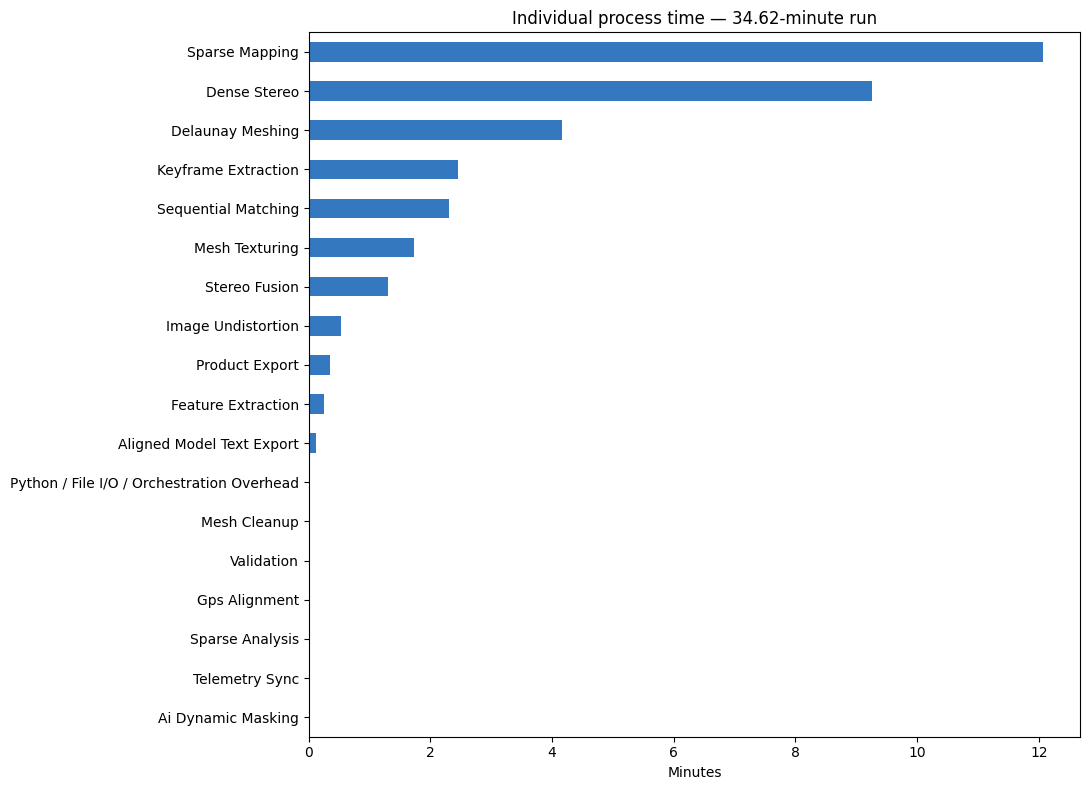

In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

report_path = f"{FULL_OUTPUT}/run_report.json"
report = json.load(open(report_path))

total_seconds = report["wall_clock_seconds"]
rows = []

for name, details in report.get("workflow_steps", {}).items():
    seconds = float(details.get("seconds", 0))
    rows.append({
        "category": "Workflow",
        "process": name.replace("_", " ").title(),
        "seconds": seconds,
    })

for name, details in report.get("stages", {}).items():
    seconds = float(details.get("seconds", 0))
    rows.append({
        "category": "Reconstruction",
        "process": name.replace("_", " ").title(),
        "seconds": seconds,
    })

recorded_seconds = sum(row["seconds"] for row in rows)
overhead_seconds = max(0, total_seconds - recorded_seconds)

rows.append({
    "category": "Pipeline",
    "process": "Python / File I/O / Orchestration Overhead",
    "seconds": overhead_seconds,
})

timing_table = pd.DataFrame(rows)
timing_table["minutes"] = timing_table["seconds"] / 60
timing_table["percent_of_total"] = (
    timing_table["seconds"] / total_seconds * 100
)
timing_table = timing_table.sort_values(
    "seconds", ascending=False
).reset_index(drop=True)

display(
    timing_table.style.format({
        "seconds": "{:.2f}",
        "minutes": "{:.2f}",
        "percent_of_total": "{:.2f}%",
    })
)

print("Total recorded runtime:", round(total_seconds / 60, 2), "minutes")
print("Sum of measured processes:", round(recorded_seconds / 60, 2), "minutes")
print("Unmeasured overhead:", round(overhead_seconds / 60, 2), "minutes")

ax = timing_table.sort_values("minutes").plot.barh(
    x="process",
    y="minutes",
    figsize=(11, 8),
    legend=False,
    color="#3478bf",
    title="Individual process time — 34.62-minute run",
)
ax.set_xlabel("Minutes")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(
    f"{EXPERIMENT_ROOT}/final_individual_process_times.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

timing_table.to_csv(
    f"{EXPERIMENT_ROOT}/final_individual_process_times.csv",
    index=False,
)

## Decision boundary

The final candidate is adopted only when `final_decision.json` reports `recommended: true`.
The stronger final gates retain at least 95% of the accepted 1088 point count and DSM coverage,
preserve the same 253 source frames, require at least a 5% end-to-end speed improvement, and keep
camera registration, reprojection, GPS residual, and mesh connectivity within fixed limits.
Neither the sparse screen nor the final structural comparison replaces independent surveyed
surface checkpoints.